In [1]:
%env WANDB_START_METHOD=thread
%env WANDB_PROJECT=pretraining_BERT_the_notebook

env: WANDB_START_METHOD=thread
env: WANDB_PROJECT=pretraining_BERT_the_notebook


In [2]:
import json
from pathlib import Path
from typing import Iterator
import time

import datasets
import matplotlib.pyplot as plt
import pandas as pd
import torch
from magic_timer import MagicTimer
from tokenizers import BertWordPieceTokenizer, Regex, normalizers
from tqdm import tqdm
from transformers import (
    BertConfig,
    BertForMaskedLM,
    BertTokenizerFast,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

from typing import Union, Iterator
from pathlib import Path
import os
import tempfile

import numpy as np
from magic_timer import MagicTimer
import datasets
from tokenizers import BertWordPieceTokenizer, Regex, normalizers
from tqdm.notebook import tqdm
import time
from transformers import (
    BertTokenizerFast,
)
import torch

from token_writer import TokenWriter, load_tokens, DTYPE

RUN_DIR = Path("data") / f"run_{time.strftime('%Y%m%d-%H%M%S')}"
TOKENIZER_PATH = "tokenizer.json"
CHECKPOINT_DIR = RUN_DIR / "training_checkpoints"
MODEL_DIR = RUN_DIR / "model"
TRAINER_HISTORY_PATH = RUN_DIR / "trainer_history.json"
VOCAB_SIZE = 32_768  # from Cramming
DEVICE_BATCH_SIZE = 36  # adjust to get near 100% gpu memory use
MODEL_MAX_SEQ_LEN = 128  # from Cramming
TOKENS_FILE = "bookcorpus_wiki_tokens.bin"
LIMIT_DATASET = 2016 * 4  # keep small for development, set to None for full dataset
RANDOM_SEED = 42
DEVICE_BATCH_SIZE = 36  # adjust to get near 100% gpu memory use
MODEL_MAX_SEQ_LEN = 128  # from Cramming
gradient_accumulation_steps = 2048 // DEVICE_BATCH_SIZE  # roughly based on Cramming
batch_size = DEVICE_BATCH_SIZE * gradient_accumulation_steps
print(f"{DEVICE_BATCH_SIZE = }")
print(f"{gradient_accumulation_steps = }")
print(f"{batch_size = }")

DEVICE_BATCH_SIZE = 36
gradient_accumulation_steps = 56
batch_size = 2016


In [3]:
assert torch.cuda.is_available()

In [4]:
# # Train a tokenizer
# assert not Path(TOKENIZER_PATH).exists(), "Tokenizer already exists"
# with MagicTimer() as timer:
#     dataset = datasets.load_dataset(
#         "sradc/chunked-shuffled-wikipedia20220301en-bookcorpusopen",
#         split="train",
#         revision="0e6fada2dd43136e4a3f637da41de2e596aee674",
#     )
# print(f"Loaded dataset in {timer}")
# tokenizer = BertWordPieceTokenizer()
# tokenizer._tokenizer.normalizer = normalizers.Sequence(
#     [
#         normalizers.Replace(Regex("(``|'')"), '"'),
#         normalizers.NFD(),
#         normalizers.Lowercase(),
#         normalizers.StripAccents(),
#         normalizers.Replace(Regex(" {2,}"), " "),
#         normalizers.Replace(Regex(r"[^\x00-\x7F]+"), ""),
#     ]
# )  # Normalizer based on, https://github.com/JonasGeiping/cramming/blob/50bd06a65a4cd4a3dd6ee9ecce1809e1a9085374/cramming/data/tokenizer_preparation.py#L52

# def tokenizer_training_data() -> Iterator[str]:
#     for i in tqdm(
#         range(len(dataset)),
#         desc="Feeding samples to tokenizer",
#     ):
#         yield dataset[i]["text"]


# with MagicTimer() as timer:
#     tokenizer.train_from_iterator(
#         tokenizer_training_data(),
#         vocab_size=VOCAB_SIZE,
#         min_frequency=2,
#     )
# print(f"Tokenizer trained in {timer}.")
# assert np.all(
#     np.array(list(tokenizer.get_vocab().values())) >= 0
# ), "make sure no negative ids, because using unsigned ints to save to disk"
# tokenizer.save(str(TOKENIZER_PATH))

In [5]:
# # Tokenize corpus and stream bytes to file
# %env TOKENIZERS_PARALLELISM=true
# tokenizer = BertTokenizerFast(tokenizer_file=str(TOKENIZER_PATH))
# with MagicTimer() as timer:
#     # use unshuffled dataset and shuffle after tokenization
#     dataset = datasets.load_dataset(
#         "sradc/chunked-wikipedia20220301en-bookcorpusopen",
#         split="train",
#         revision="3b060686dc821da895a86ac05198f980894f63fa",
#     )
# print(f"Loaded dataset in {timer}")
# with MagicTimer() as timer, TokenWriter(TOKENS_FILE) as writer:
#     for i in tqdm(
#         range(len(dataset)),
#         desc="Tokenizing",
#     ):
#         tokens = np.array(tokenizer(dataset[i]["text"])["input_ids"], dtype=DTYPE)
#         writer.write(tokens)
# print(f"Tokenized dataset in {timer}.")

In [6]:
# tokens = load_tokens(TOKENS_FILE)
# print(f"Loaded {len(tokens)} tokens.")
# # Get an idea of speed of loading tokens
# for i in tqdm(range(10_000_000)):
#     tok = tokens[i]
# # 2854375 tokens/s... not bad

In [7]:
# for i in tqdm(range(0, 5687682679, 5687682679 // 100000)):
#     tok = tokens[i]
# # ~6500 tokens/s with ~random access

In [8]:
# seq_length = 128
# num_batches = len(tokens) // seq_length
# batch_idx_shuffled = np.random.permutation(num_batches)
# for batch_idx in tqdm(batch_idx_shuffled[:10_000]):
#     tok = tokens[batch_idx * seq_length : (batch_idx + 1) * seq_length]
#     # text = tokenizer.decode(tok)
# # text

In [9]:
class TokenizedDataset(torch.utils.data.Dataset):
    def __init__(self):
        self.tokens_array = load_tokens(TOKENS_FILE)
        rng = np.random.default_rng(RANDOM_SEED)  # reproducible shuffling, important for parallel loading
        self.shuffled_idx = rng.permutation(
            len(self.tokens_array) // MODEL_MAX_SEQ_LEN
        )
        if LIMIT_DATASET:
            self.shuffled_idx = self.shuffled_idx[:LIMIT_DATASET]

    def __len__(self):
        return len(self.shuffled_idx)

    def __getitem__(self, i):
        idx = self.shuffled_idx[i]
        tokens = self.tokens_array[
            idx * MODEL_MAX_SEQ_LEN : (idx + 1) * MODEL_MAX_SEQ_LEN
        ]
        return torch.tensor(tokens.astype(np.int64), dtype=torch.int64)


tokenized_dataset = TokenizedDataset()
# Get idea of speed of loading tokens
for i in tqdm(range(5000)):
    torch.sum(tokenized_dataset[i])

  0%|          | 0/5000 [00:00<?, ?it/s]

In [10]:
model_config = BertConfig(
    vocab_size=VOCAB_SIZE,
    max_position_embeddings=MODEL_MAX_SEQ_LEN,
    attention_probs_dropout_prob=0,  # cramming says no dropout
    hidden_dropout_prob=0,  # cramming says no dropout
)
model = BertForMaskedLM(model_config)
tokenizer = BertTokenizerFast(tokenizer_file=str(TOKENIZER_PATH))
data_collator = DataCollatorForLanguageModeling(
    tokenizer=tokenizer,
    mlm=True,
    mlm_probability=0.15,
    return_tensors="pt",
)

In [11]:
training_args = TrainingArguments(
    # Optimizer values are from Cramming
    learning_rate=1e-3,
    warmup_ratio=0.5,
    adam_beta1=0.9,
    adam_beta2=0.98,
    adam_epsilon=1e-9,
    weight_decay=0.01,
    max_grad_norm=0.5,
    num_train_epochs=1,
    per_device_train_batch_size=DEVICE_BATCH_SIZE,
    gradient_accumulation_steps=gradient_accumulation_steps,
    dataloader_num_workers=4,
    save_steps=60,
    save_total_limit=2,
    logging_steps=1,
    output_dir=CHECKPOINT_DIR,
    optim="adamw_torch",
    report_to="wandb",
)
Trainer._get_train_sampler = lambda _: None  # prevent shuffling the dataset again
trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    train_dataset=tokenized_dataset,
)

In [12]:
# Avoid warning about parallelism. We only needed it for the training above,
# (we have enough time in between batches to tokenize).
%env TOKENIZERS_PARALLELISM=false

with MagicTimer() as timer:
    trainer.train()
print(f"Trained model in {timer}.")
trainer.save_model(str(MODEL_DIR))
TRAINER_HISTORY_PATH.write_text(json.dumps(trainer.state.log_history))

env: TOKENIZERS_PARALLELISM=false


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: sradc. Use `wandb login --relogin` to force relogin


Step,Training Loss
1,10.526800
2,10.523500
3,9.824100
4,9.101000


Trained model in 1.6 minutes.


459

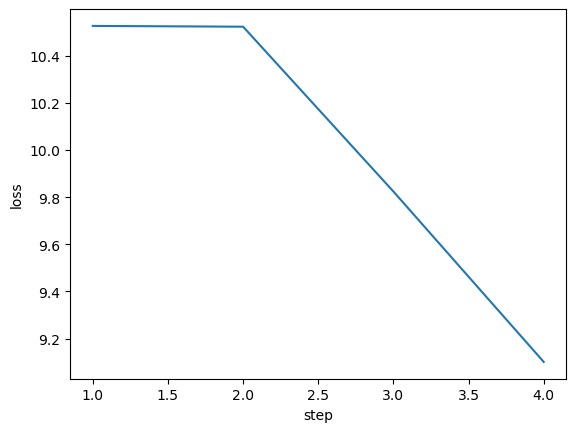

In [13]:
trainer_history = pd.DataFrame(trainer.state.log_history[:-1]).set_index("step")
trainer_history.loss.plot(label="loss")
plt.ylabel("loss")
plt.savefig(RUN_DIR / "loss.png")